# Chapter 9. Plotting and Visualization
- The project was started by John Hunter in 2002 to enable a MATLAB-like plotting interface in Python.

In [1]:
%matplotlib notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 9.1 A Brief matplotlib API Primer

### Figures and Subplots

<IPython.core.display.Javascript object>


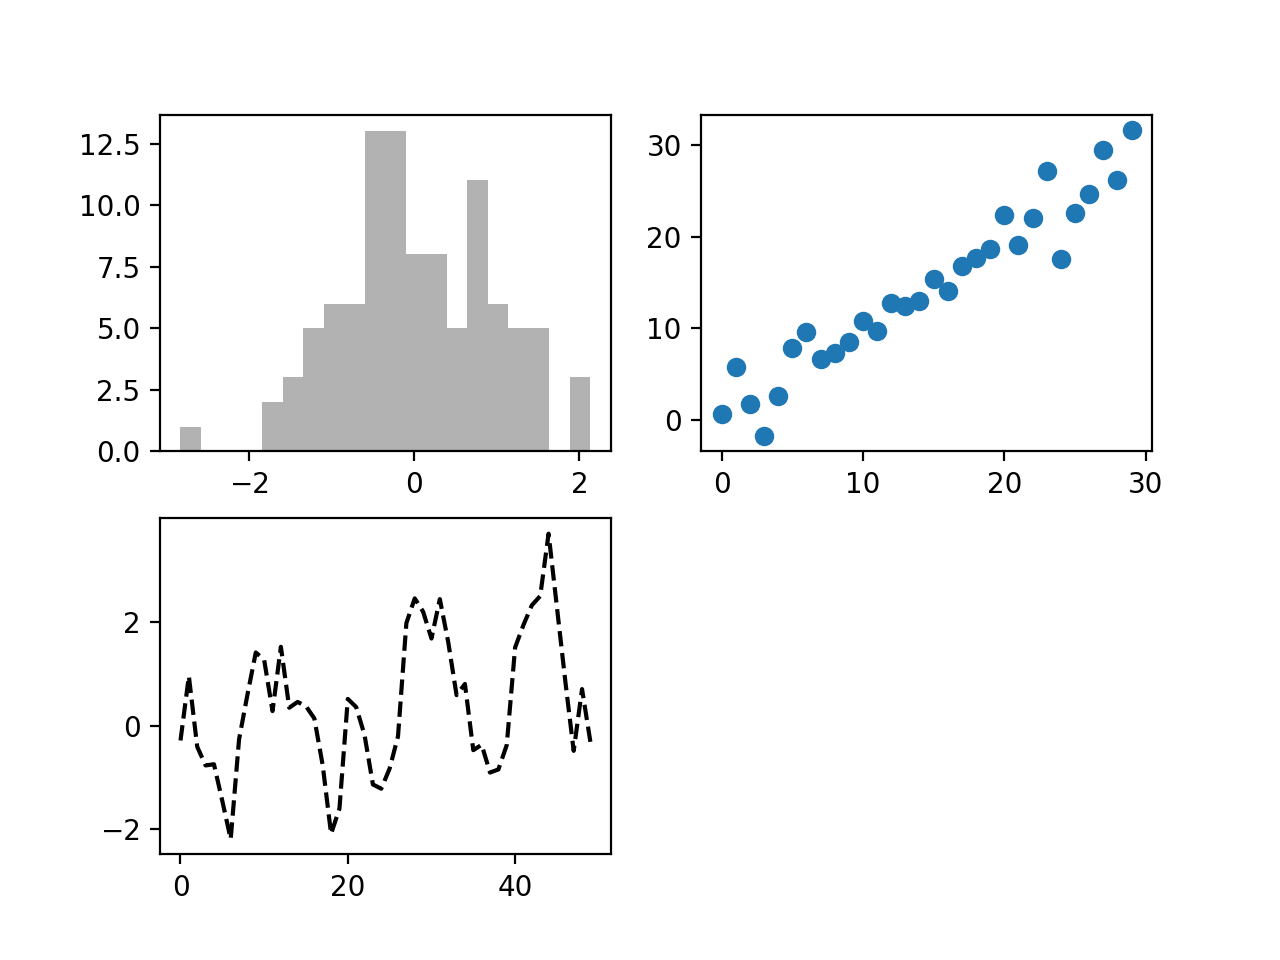

In [29]:
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)

In [30]:
# matplotlib draws on the last figure
plt.plot(np.random.randn(50).cumsum(), 'k--') 

In [31]:
ax1.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)

(array([ 1.,  0.,  0.,  0.,  2.,  3.,  5.,  6.,  6., 13., 13.,  8.,  8.,
         5., 11.,  6.,  5.,  5.,  0.,  3.]),
 array([-2.82995275, -2.5817524 , -2.33355206, -2.08535171, -1.83715137,
        -1.58895102, -1.34075068, -1.09255033, -0.84434998, -0.59614964,
        -0.34794929, -0.09974895,  0.1484514 ,  0.39665174,  0.64485209,
         0.89305244,  1.14125278,  1.38945313,  1.63765347,  1.88585382,
         2.13405416]),
 <BarContainer object of 20 artists>)

In [32]:
ax2.scatter(np.arange(30), np.arange(30)+3*np.random.randn(30))

> - Creating a figure with a grid of subplot is a very common task, so matplotlib includes a convenience method, ***plt.subplots***, that creates a new figure and returns a Numpy array containing the created subplot objects:

<IPython.core.display.Javascript object>


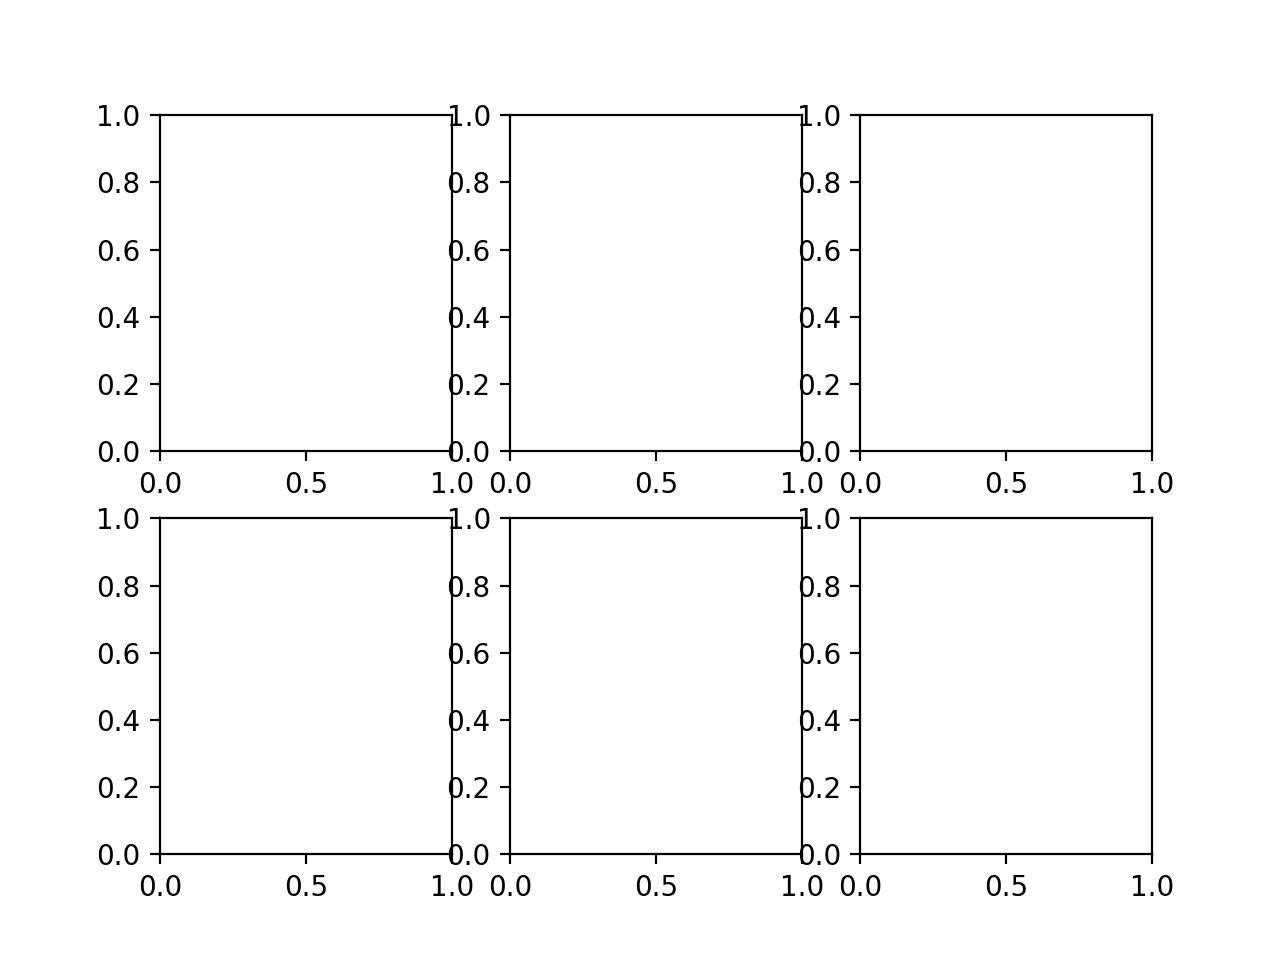

array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

In [34]:
fig, axes = plt.subplots(2,3)
axes

- The axes array can be easily indexed like a two-dimensional array; for example, ***axes[0,1]***
- You can also indicate that subplots should have the same x- or y-axis using ***sharex*** and ***sharey***, respectively.

> 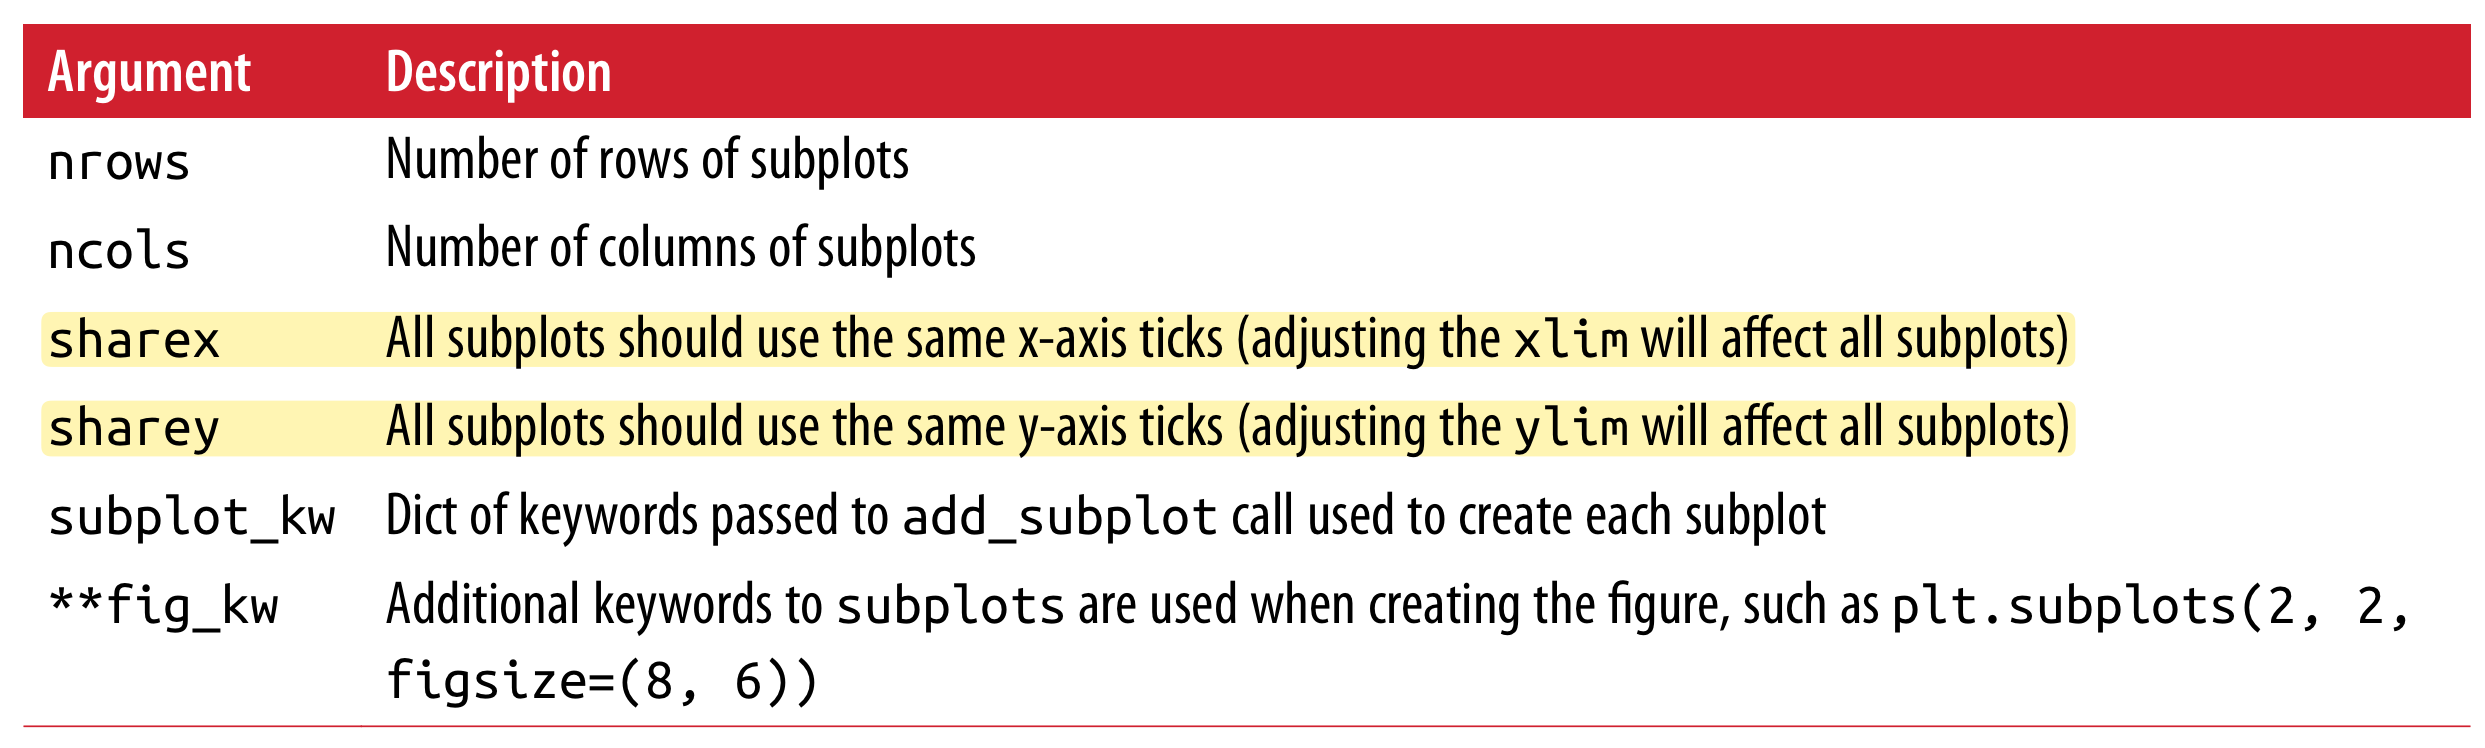

### Adjusting the spacing around subplots
- You can change the spacing using the ***subplots_adjust*** method on **Figure** objects, also available as a top-level function:
- ***subplots_adjust(left= , bottom= , right= , top=, wspace=, hspace= )***
- ***wspace*** and ***hspace*** controls the percent of the figure width and figure height, respectively, to use as spacing between subplots.

<IPython.core.display.Javascript object>


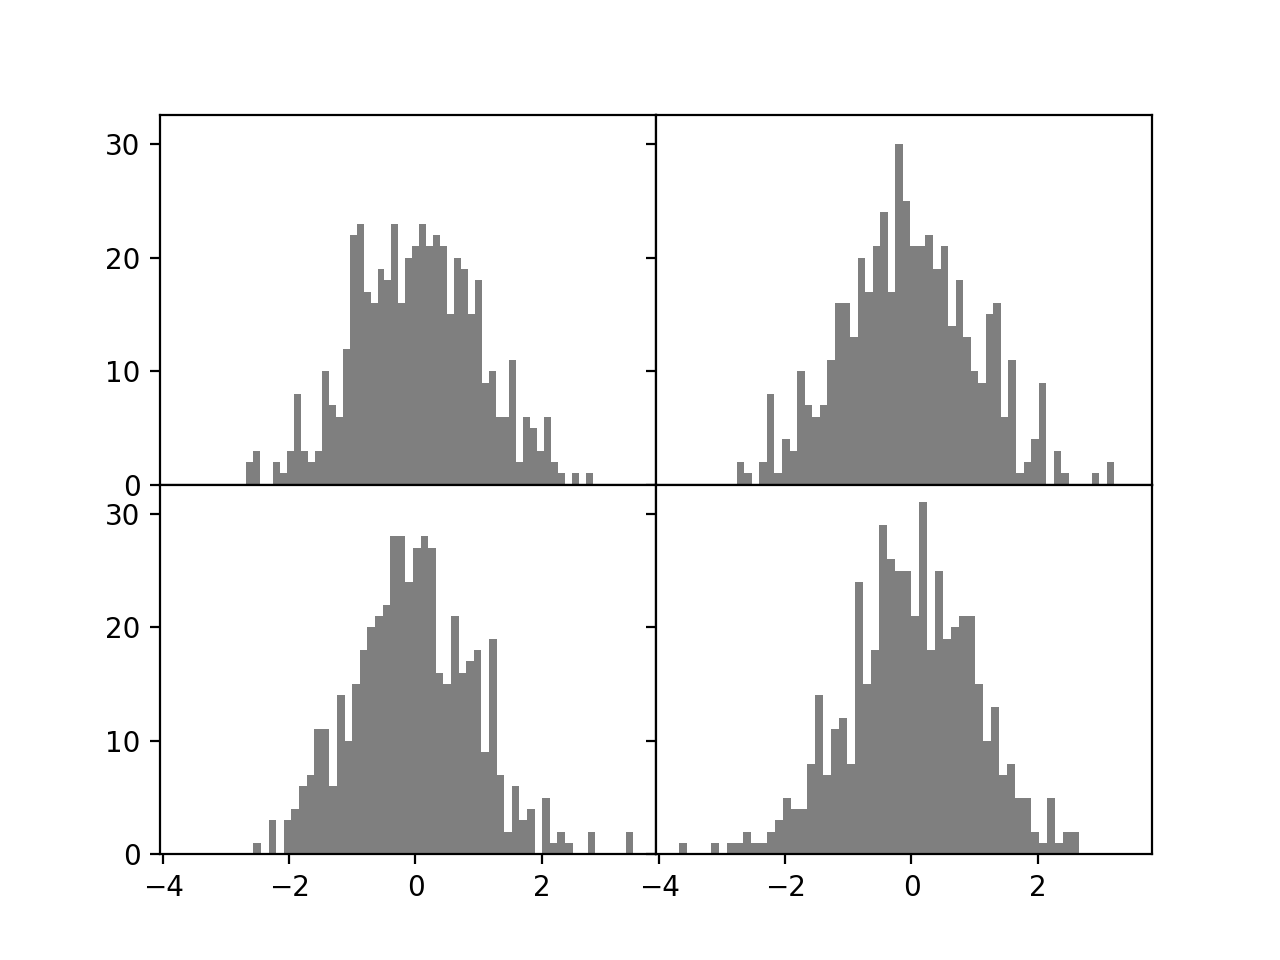

In [36]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i,j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

### Colors, Markers, and Line Styles

> - For line plots, you will notice that subsequent points are linearly interpolated by default. This can be altered with the ***drawstyle*** option

In [3]:
data = np.random.randn(30).cumsum()

<IPython.core.display.Javascript object>


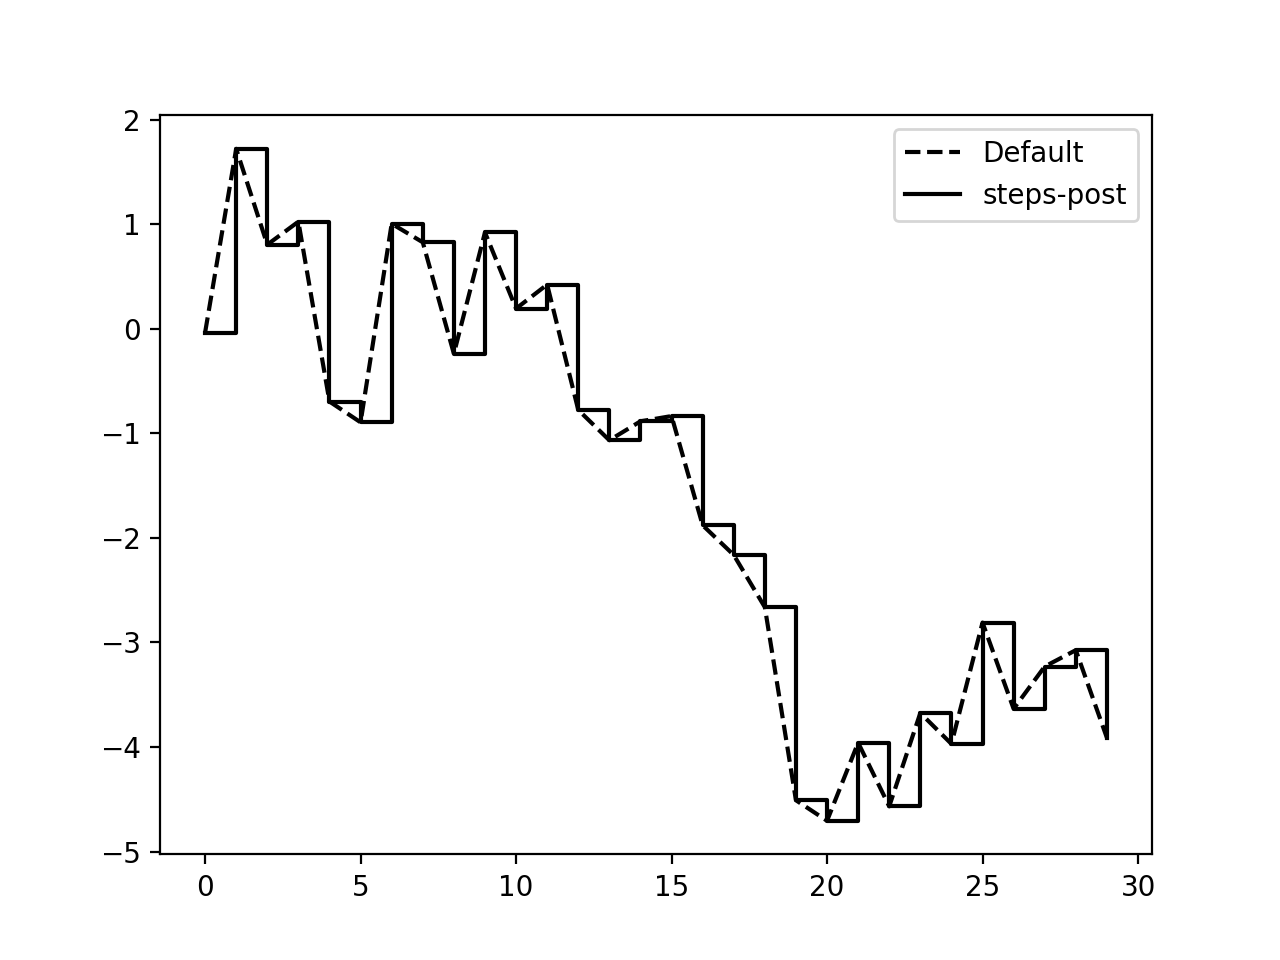

In [4]:
plt.plot(data, 'k--', label='Default')

In [5]:
plt.plot(data, 'k-', drawstyle='steps-post', label='steps-post')

In [6]:
plt.legend(loc='best')

### Ticks, Labels, and Legends
- There are two main ways: using the procedural **pyplot interface** and the more object-oriented **native matplotlib API**.

- 1. pyplot interface
    > - Called with no arguments returns the current parameter value(e.g., ***plt.xlim()*** returns the current x-axis plotting range
    > - Called with parameters sets the parameter value (e.g., ***plt.xlim([0,10])***, sets the x-axis range to 0 to 10)
    > - All such methods act on the active or most recently created *AxesSubplot*.

- 2. Subplot object itself = Subplot instance methods
    > - ***ax.get_xlim***
    > - ***ax.set_xlim***
    > - 해당 방법을 더 자주 사용해볼 것: 여러 subplot 사용 시 유리

#### Setting the title, axis labels, ticks, and ticklabels

<IPython.core.display.Javascript object>


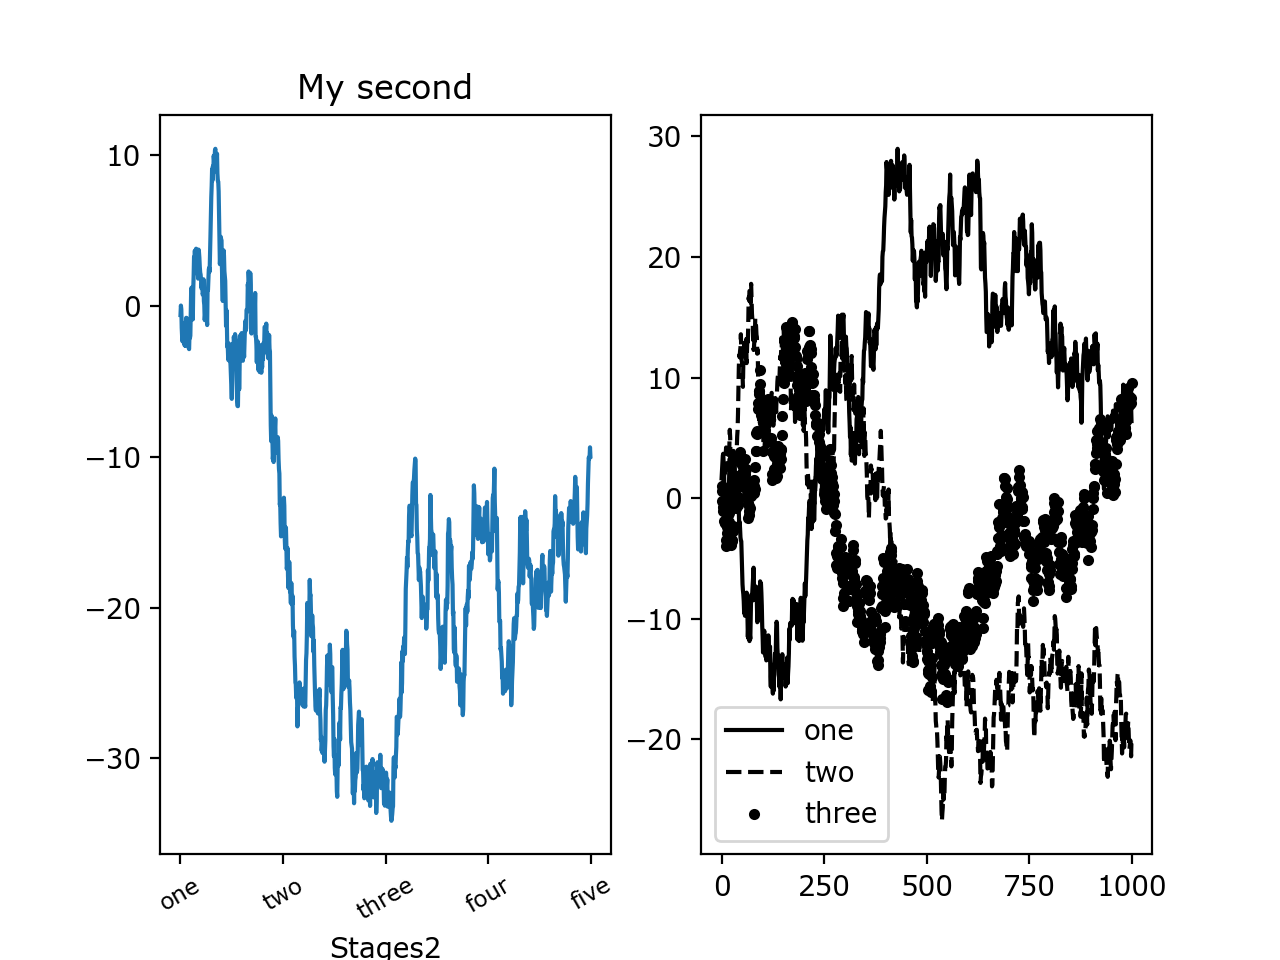

In [3]:
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.plot(np.random.randn(1000).cumsum())

> - ***set_xticks*** : Instructing matplotlib where to place the ticks along the data range; by default these locations will also be the labels
> - ***set_xticklabels*** : Setting any other values as the labels

In [4]:
ticks = ax.set_xticks([0,250,500,750,1000])

In [5]:
labels = ax.set_xticklabels(['one','two','three','four','five'], rotation=30, fontsize='small')

In [6]:
ax.set_xlabel('Stages')

Text(0.5, 24.313360157402354, 'Stages')

In [7]:
ax.set_title('My first')

Text(0.5, 1.0, 'My first')

- Modifying the y-axis consists of the same process, substituting y for x in the above.

> - The axes class has a ***set*** method that allows **batch** setting of plot properties.

In [8]:
props = {'title': 'My second', 'xlabel':'Stages2'}
ax.set(**props)

[Text(0.5, 1.0, 'My second'), Text(0.5, 24.313360157402354, 'Stages2')]

#### Adding legends

In [9]:
from numpy.random import randn
ax2 = fig.add_subplot(1,2,2)
ax2.plot(randn(1000).cumsum(), 'k', label='one')

In [10]:
ax2.plot(randn(1000).cumsum(), 'k--', label='two')

In [11]:
ax2.plot(randn(1000).cumsum(), 'k.', label='three')

In [12]:
ax2.legend(loc='best') # = plt.legend()

- To exclude one or more elements from the legend, pass no label or ***label='\_nolegend\_'***

### Annotations and Drawing on a Subplot
- ***text, arrow*** and ***annotate*** function

> - ***text*** draws text at given coordinates(x,y) on the plot with optional custom styling
> - The ***ax.annotate*** method can draw labels at the indicated x and y coordinates.

<IPython.core.display.Javascript object>


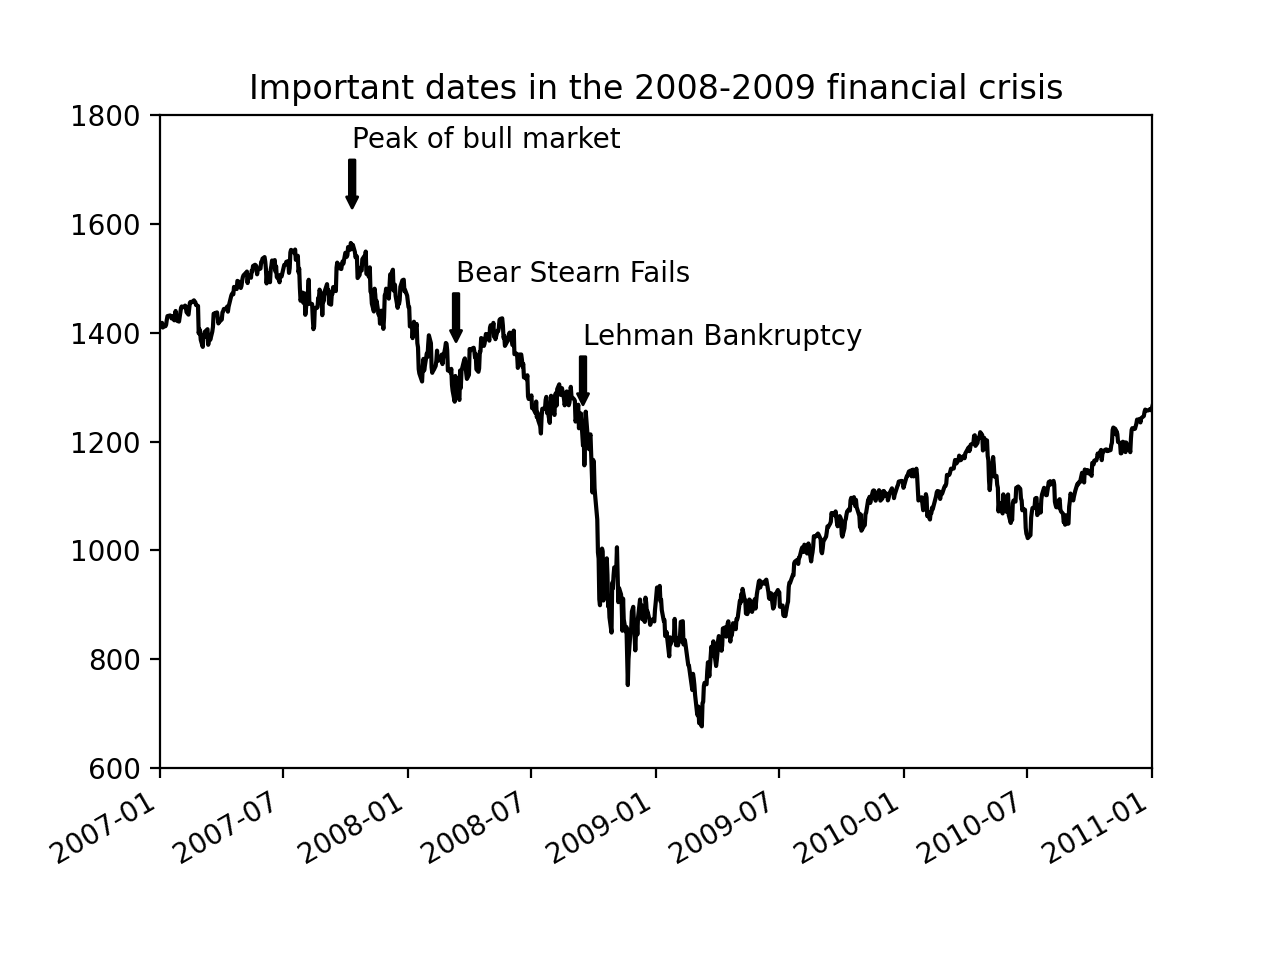

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

In [18]:
from datetime import datetime

fig = plt.figure()
ax4 = fig.add_subplot(1,1,1)

data = pd.read_csv('Examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']

spx.plot(ax=ax4, style='k-')

crisis_data = [
    (datetime(2007,10,11), 'Peak of bull market'),
    (datetime(2008,3,12), 'Bear Stearn Fails'),
    (datetime(2008,9,15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    ax4.annotate(label, xy=(date, spx.asof(date)+75),
                xytext=(date, spx.asof(date)+225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom in on 2007-2010
ax4.set_xlim(['1/1/2007', '1/1/2011'])
ax4.set_ylim([600, 1800])

ax4.set_title('Important dates in the 2008-2009 financial crisis')

#ax4.plot(np.random.randn(1000).cumsum())
#ax4.text(200,10, 'Hello World!')

> - matplotlib has objects that represent many common shapes, referred to as *patches*. Some of these, like ***Retangle*** and ***Circle***, are found in ***matplotlib.pyplot***, but the full set is located in ***matplotlib.patches***. 

<IPython.core.display.Javascript object>


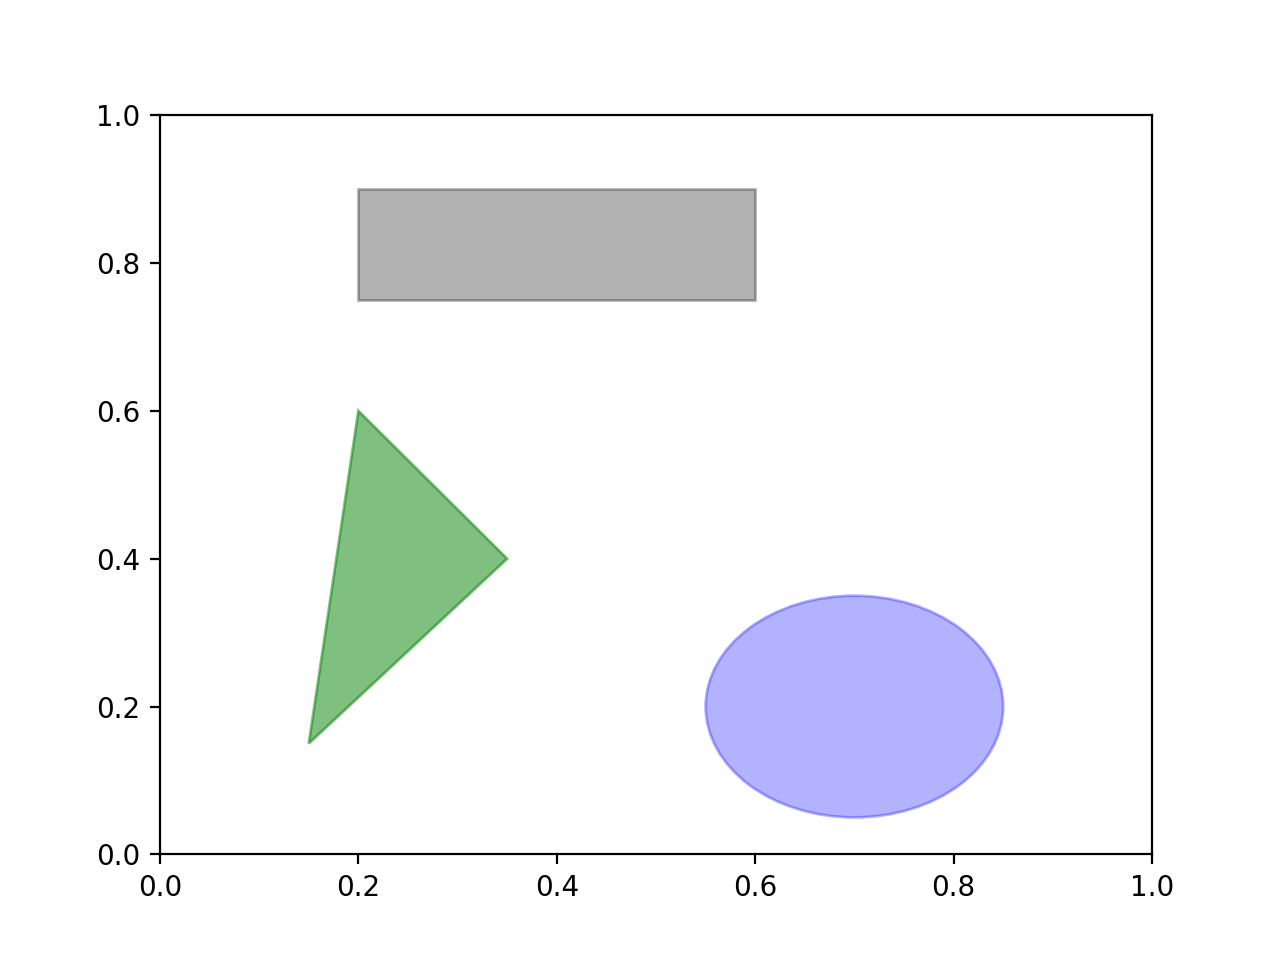

In [21]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

rect = plt.Rectangle((0.2,0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7,0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15,0.15],[0.35,0.4],[0.2,0.6]], color='g', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving Plots to File
- You can save the active figure to file using ***plt.savefig('filename')***. This method is equivalent to the figure object's ***savefig*** instance method.
>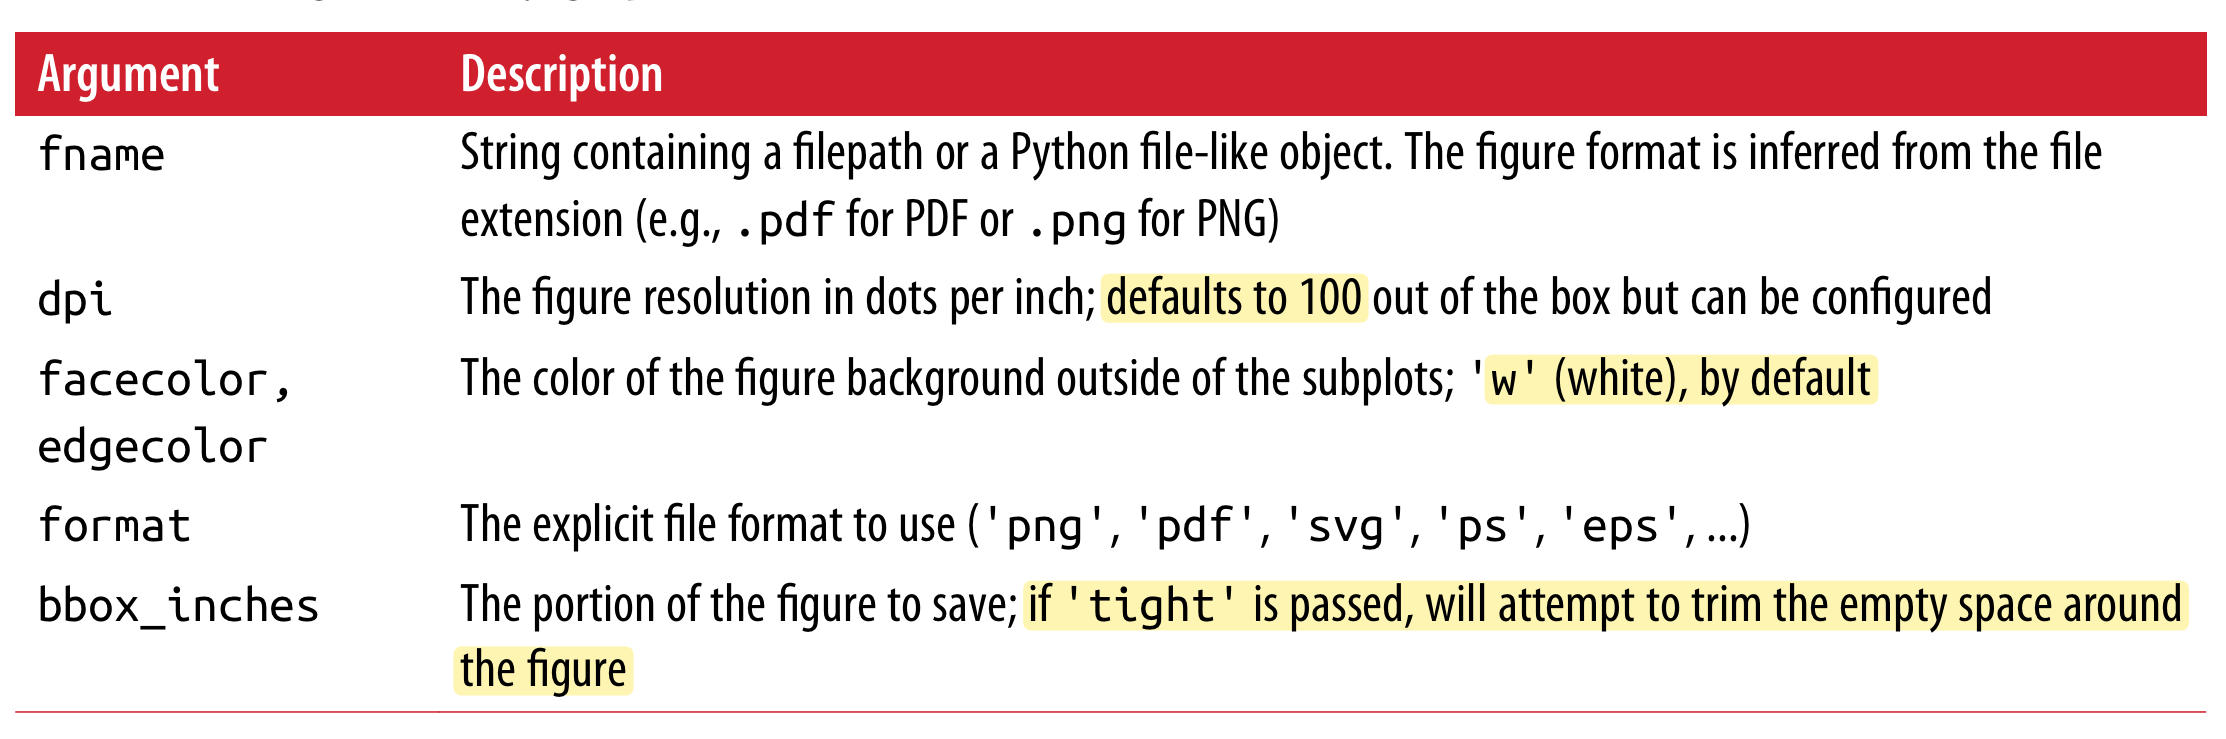

### matplotlib Configuration (Skip)
- One way to modify the configuration programmatically from Python is to use the ***rc*** method
- For extensive customization and to see a list of all the options, matplotlib comes with a configuration file ***maplotlibrc*** in the ***matplotlib/mpl-data*** directory
- If you customize the file and place it in your home directory titled ***.matplotlibrc***, it will be loaded each time you use maplotlib
- The ***seaborn*** package has several built-in plot themes or styles that use matplotlib's configuration system internally.